#  Production-Grade ReAct Agent — Advanced Architecture
> **Full LangGraph ReAct agent** with multi-tool routing, persistent SQLite memory,  
> streaming output, retry logic, structured logging, graceful error handling,  
> multi-LLM fallback, and a rich tool suite.

---
### Architecture Overview
```
User Query
    │
    ▼
┌──────────────────────────────────────────┐
│          ReAct Agent Graph               │
│                                          │
│  ┌────────────┐    tool_calls?    ┌────────────┐ │
│  │  LLM Node  │ ────────────────► │ Tool Node  │ │
│  │(w/ system  │ ◄──────────────── │(7 tools)   │ │
│  │  prompt)   │   tool results    └────────────┘ │
│  └────────────┘                                  │
│        │ no tool_calls                           │
│        ▼                                         │
│      END                                         │
└──────────────────────────────────────────┘
         │
         ▼
  SQLite Memory (persistent across restarts)
```


##  1. Install & Import Dependencies

In [1]:
# Install all required packages  (run once; skip if already installed)
%pip install -q \
    langchain langchain-community langchain-groq langchain-openai \
    langgraph langgraph-checkpoint-sqlite \
    python-dotenv arxiv wikipedia tavily-python \
    pydantic rich


In [2]:
# ──────────────────────────────────────────────────────────────────────────────
# Core imports — all in one place for clarity
# ──────────────────────────────────────────────────────────────────────────────
from __future__ import annotations

import os
import re
import time
import math
import json
import logging
import sqlite3
import traceback
from datetime import datetime
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union
from typing_extensions import Annotated, TypedDict

# ── LangChain core ───────────────────────────────────────────────────────────
from langchain_core.messages import (
    AIMessage, HumanMessage, SystemMessage, ToolMessage, AnyMessage
)
from langchain_core.tools import tool
from langchain_core.runnables import RunnableConfig
from langchain_core.callbacks import BaseCallbackHandler

# ── LangChain community tools ─────────────────────────────────────────────────
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_community.tools.tavily_search import TavilySearchResults

# ── LLM providers ────────────────────────────────────────────────────────────
from langchain_groq import ChatGroq

# ── LangGraph ────────────────────────────────────────────────────────────────
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver

# ── Display helpers ──────────────────────────────────────────────────────────
from IPython.display import Image, display, Markdown
from pprint import pformat
import warnings

warnings.filterwarnings("ignore")
print(" All imports successful")


/tmp/ipykernel_4418/2540237256.py:27: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun


All imports successful


##  2. Configuration, Environment & Structured Logging

In [3]:
# Configuration — centralised, validated, easy to swap

import os
import logging
from dotenv import load_dotenv

load_dotenv()

# ── Set API Key directly for notebook (.ipynb) ───────────────────────────────
os.environ["GROQ_API_KEY"] ="your api key"

# ── Agent config ──────────────────────────────────────────────────────────────
AGENT_CONFIG = {
    "primary_model":   "llama-3.3-70b-versatile",
    "fallback_model":  "gemma2-9b-it",
    "temperature":     0.0,
    "max_tokens":      4096,
    "max_iterations":  10,
    "request_timeout": 30,
    "db_path":         "agent_memory.db",
    "langchain_project": "ReAct_Agent_Production",
}

# ── Required env vars ─────────────────────────────────────────────────────────
REQUIRED_KEYS = {
    "GROQ_API_KEY": "your api key",
}

missing = [k for k in REQUIRED_KEYS if not os.getenv(k)]

if missing:
    msgs = [f"  • {k}: {REQUIRED_KEYS[k]}" for k in missing]
    raise EnvironmentError(
        "Missing required environment variables:\n" + "\n".join(msgs)
    )

# ── LangSmith tracing (optional) ─────────────────────────────────────────────
if os.getenv("LANGCHAIN_API_KEY"):
    os.environ["LANGCHAIN_TRACING_V2"] = "true"
    os.environ["LANGCHAIN_PROJECT"] = AGENT_CONFIG["langchain_project"]
    print(" LangSmith tracing enabled")

# ── Logging ───────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s — %(message)s",
    datefmt="%H:%M:%S",
)

logger = logging.getLogger("react_agent")

print(f" Config loaded — primary model: {AGENT_CONFIG['primary_model']}")

 Config loaded — primary model: llama-3.3-70b-versatile


## 🔧 3. Production Tool Suite
7 tools — each with proper docstrings, type hints, input validation, and error handling.


In [4]:
# ── Math Tools (safe, validated) ─────────────────────────────────────────────

@tool
def add(a: float, b: float) -> str:
    """Add two numbers together.

    Args:
        a: First number (integer or float).
        b: Second number (integer or float).

    Returns:
        Formatted string with result.
    """
    result = a + b
    logger.debug(f"add({a}, {b}) = {result}")
    return f"{a} + {b} = {result}"


@tool
def subtract(a: float, b: float) -> str:
    """Subtract b from a.

    Args:
        a: Number to subtract from.
        b: Number to subtract.

    Returns:
        Formatted string with result.
    """
    result = a - b
    return f"{a} - {b} = {result}"


@tool
def multiply(a: float, b: float) -> str:
    """Multiply two numbers.

    Args:
        a: First number.
        b: Second number.

    Returns:
        Formatted string with result.
    """
    result = a * b
    return f"{a} × {b} = {result}"


@tool
def divide(a: float, b: float) -> str:
    """Divide a by b.  Returns an error message if b is zero.

    Args:
        a: Dividend.
        b: Divisor (must not be zero).

    Returns:
        Formatted string with result, or clear error message.
    """
    if b == 0:
        return " Error: Division by zero is undefined."
    result = a / b
    return f"{a} ÷ {b} = {result:.6g}"


@tool
def power(base: float, exponent: float) -> str:
    """Raise base to the power of exponent.

    Args:
        base: The base number.
        exponent: The exponent.

    Returns:
        Formatted string with result.
    """
    try:
        result = math.pow(base, exponent)
        return f"{base}^{exponent} = {result:.6g}"
    except (OverflowError, ValueError) as e:
        return f" Math error: {e}"


@tool
def calculate(expression: str) -> str:
    """Safely evaluate a mathematical expression string.

    Supports: +, -, *, /, **, %, //, parentheses, and math functions
    (sqrt, sin, cos, tan, log, log10, abs, round, floor, ceil, pi, e).

    Args:
        expression: A mathematical expression, e.g. 'sqrt(144) + 2**8'.

    Returns:
        Result as a string, or a descriptive error message.
    """
    # Whitelist: only safe characters
    allowed = re.compile(r'^[0-9\s\+\-\*\/\(\)\.\%\,a-z_]+$', re.IGNORECASE)
    if not allowed.match(expression):
        return f" Unsafe expression rejected: {expression!r}"
    safe_globals: Dict[str, Any] = {
        "__builtins__": {},
        "sqrt": math.sqrt, "sin": math.sin, "cos": math.cos,
        "tan": math.tan,  "log": math.log, "log10": math.log10,
        "abs": abs,       "round": round,  "floor": math.floor,
        "ceil": math.ceil,"pi": math.pi,   "e": math.e,
        "pow": pow,
    }
    try:
        result = eval(expression, safe_globals)         # noqa: S307
        return f"{expression} = {result}"
    except ZeroDivisionError:
        return " Division by zero."
    except Exception as exc:
        return f" Could not evaluate '{expression}': {exc}"


print(" Math tools defined (add, subtract, multiply, divide, power, calculate)")


 Math tools defined (add, subtract, multiply, divide, power, calculate)


In [5]:
# ──────────────────────────────────────────────────────────────────────────────
# ── Search & Knowledge Tools ──────────────────────────────────────────────────
# ──────────────────────────────────────────────────────────────────────────────

# ── ArXiv (academic papers) ──────────────────────────────────────────────────
_arxiv_wrapper = ArxivAPIWrapper(
    top_k_results=3,
    doc_content_chars_max=1500,
    load_all_available_meta=True,
)
arxiv_tool = ArxivQueryRun(
    api_wrapper=_arxiv_wrapper,
    description=(
        "Search ArXiv for academic papers, research, and scientific publications. "
        "Best for: AI/ML papers, math, physics, CS, biology. "
        "Input: keywords or paper title."
    ),
)

# ── Wikipedia ────────────────────────────────────────────────────────────────
_wiki_wrapper = WikipediaAPIWrapper(
    top_k_results=2,
    doc_content_chars_max=2000,
    lang="en",
)
wiki_tool = WikipediaQueryRun(
    api_wrapper=_wiki_wrapper,
    description=(
        "Search Wikipedia for encyclopedic information about concepts, "
        "people, places, events, and definitions. "
        "Input: topic or concept name."
    ),
)

# ── Tavily Web Search (graceful degradation if key missing) ──────────────────
_TAVILY_KEY = os.getenv("TAVILY_API_KEY")
if _TAVILY_KEY:
    tavily_tool = TavilySearchResults(
        max_results=5,
        search_depth="advanced",
        include_answer=True,
        include_raw_content=False,
        include_images=False,
        description=(
            "Real-time web search. Use for: current events, latest news, "
            "live prices, recent releases, anything that changes over time. "
            "Input: a clear search query."
        ),
    )
    print(" Tavily web search enabled")
else:
    # Fallback stub so the tools list never breaks at runtime
    @tool
    def tavily_tool(query: str) -> str:  # type: ignore[misc]
        """Real-time web search (currently unavailable — set TAVILY_API_KEY to enable)."""
        return (
            " Web search unavailable: TAVILY_API_KEY not set. "
            "Try Wikipedia or ArXiv for factual queries."
        )
    print("  Tavily not configured — using stub (set TAVILY_API_KEY for live search)")

# ── Datetime tool ─────────────────────────────────────────────────────────────
@tool
def get_current_datetime(timezone: str = "UTC") -> str:
    """Return the current date and time.

    Args:
        timezone: Timezone label (informational only; returns UTC clock).

    Returns:
        ISO-8601 formatted datetime string.
    """
    now = datetime.utcnow()
    return f"Current UTC datetime: {now.strftime('%Y-%m-%d %H:%M:%S')} (requested tz: {timezone})"


# ── Master tool registry ──────────────────────────────────────────────────────
ALL_TOOLS = [
    tavily_tool,
    arxiv_tool,
    wiki_tool,
    add,
    subtract,
    multiply,
    divide,
    power,
    calculate,
    get_current_datetime,
]

print(f" Tool registry ready — {len(ALL_TOOLS)} tools loaded:")
for t in ALL_TOOLS:
    name = getattr(t, "name", getattr(t, "__name__", str(t)))
    print(f"   • {name}")


  Tavily not configured — using stub (set TAVILY_API_KEY for live search)
 Tool registry ready — 10 tools loaded:
   • tavily_tool
   • arxiv
   • wikipedia
   • add
   • subtract
   • multiply
   • divide
   • power
   • calculate
   • get_current_datetime


##  4. LLM Setup with Multi-Model Fallback

In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# Multi-LLM setup with automatic fallback
# Primary → Fallback → Exception with clear message
# ──────────────────────────────────────────────────────────────────────────────

def _build_llm(model_name: str, **kwargs) -> ChatGroq:
    """Instantiate a ChatGroq LLM with sensible defaults."""
    return ChatGroq(
        model=model_name,
        temperature=AGENT_CONFIG["temperature"],
        max_tokens=AGENT_CONFIG["max_tokens"],
        timeout=AGENT_CONFIG["request_timeout"],
        max_retries=2,
        **kwargs,
    )


def build_llm_with_fallback() -> ChatGroq:
    """Return primary LLM; fall back to secondary model on init failure."""
    try:
        llm = _build_llm(AGENT_CONFIG["primary_model"])
        logger.info(f" Primary LLM loaded: {AGENT_CONFIG['primary_model']}")
        return llm
    except Exception as primary_err:
        logger.warning(f"Primary LLM failed ({primary_err}); trying fallback…")
        try:
            llm = _build_llm(AGENT_CONFIG["fallback_model"])
            logger.info(f" Fallback LLM loaded: {AGENT_CONFIG['fallback_model']}")
            return llm
        except Exception as fallback_err:
            raise RuntimeError(
                f"Both LLMs failed.\n"
                f"  Primary  ({AGENT_CONFIG['primary_model']}): {primary_err}\n"
                f"  Fallback ({AGENT_CONFIG['fallback_model']}): {fallback_err}"
            ) from fallback_err


# Build the LLM and bind all tools
llm = build_llm_with_fallback()
llm_with_tools = llm.bind_tools(ALL_TOOLS)

print(f" LLM ready with {len(ALL_TOOLS)} tools bound")


LLM ready with 10 tools bound


##  5. Agent State Schema & System Prompt

In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# Rich agent state — extends beyond the minimal messages-only state
# ──────────────────────────────────────────────────────────────────────────────

class AgentState(TypedDict):
    """Full state passed between graph nodes."""
    messages:        Annotated[List[AnyMessage], add_messages]
    iteration_count: int          # guard against infinite loops
    error_count:     int          # track per-run errors
    session_id:      str          # for logging / analytics


# ──────────────────────────────────────────────────────────────────────────────
# System prompt — gives the agent a clear persona, tool-use rules, and style
# ──────────────────────────────────────────────────────────────────────────────
SYSTEM_PROMPT = SystemMessage(content="""\
You are an advanced AI research and reasoning assistant powered by a ReAct (Reason + Act) architecture.

## Your Core Capabilities
- **Web search**: Use `tavily_tool` for real-time news and current events.
- **Academic research**: Use `arxiv_tool` for scientific papers and cutting-edge research.
- **Encyclopedic knowledge**: Use `wiki_tool` for concepts, history, and factual grounding.
- **Mathematics**: Use `add`, `subtract`, `multiply`, `divide`, `power`, `calculate` for accurate computation.
- **Temporal awareness**: Use `get_current_datetime` when the current date/time is relevant.

## Decision-Making Rules
1. **Always reason before acting.** Think about which tool best fits the query.
2. **Use tools for computation** — never compute math in your head; delegate to math tools.
3. **Chain tools when needed.** It is fine to call multiple tools sequentially.
4. **Cite sources.** When using search results, mention where information came from.
5. **Be honest about limitations.** If a tool returns an error, say so and explain why.
6. **Be concise but complete.** Give the user exactly what they need, no filler.

## Response Style
- Use markdown formatting for clarity (bold, bullets, code blocks).
- For multi-step problems, show your reasoning step-by-step.
- Always give a clear final answer after tool use.
""")

print(" Agent state and system prompt defined")


 Agent state and system prompt defined


##  6. Graph Nodes with Error Handling & Iteration Guard

In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# Node: LLM reasoning step
# ──────────────────────────────────────────────────────────────────────────────

def llm_node(state: AgentState) -> Dict[str, Any]:
    """Core reasoning node: prepend system prompt and call the LLM."""
    iteration = state.get("iteration_count", 0)

    # Safety valve — prevent runaway loops
    if iteration >= AGENT_CONFIG["max_iterations"]:
        logger.warning(f"Max iterations ({AGENT_CONFIG['max_iterations']}) reached — stopping.")
        stop_msg = AIMessage(
            content=(
                f" I reached the maximum iteration limit "
                f"({AGENT_CONFIG['max_iterations']}) for this query. "
                "Here is my best answer based on what I gathered so far."
            )
        )
        return {"messages": [stop_msg], "iteration_count": iteration + 1}

    # Build message list: system prompt + conversation history
    full_messages: List[AnyMessage] = [SYSTEM_PROMPT] + list(state["messages"])

    try:
        response = llm_with_tools.invoke(full_messages)
        logger.info(
            f"LLM step {iteration + 1} — "
            f"tool_calls: {len(getattr(response, 'tool_calls', []))}"
        )
        return {
            "messages": [response],
            "iteration_count": iteration + 1,
        }
    except Exception as exc:
        # Graceful degradation: return an error message instead of crashing
        error_count = state.get("error_count", 0) + 1
        logger.error(f"LLM call failed (attempt {error_count}): {exc}")
        error_msg = AIMessage(
            content=(
                f" I encountered an error while processing your request: `{exc}`. "
                "Please try rephrasing, or check your API key configuration."
            )
        )
        return {
            "messages": [error_msg],
            "iteration_count": iteration + 1,
            "error_count": error_count,
        }


# ──────────────────────────────────────────────────────────────────────────────
# ToolNode wraps all tools and handles individual tool errors gracefully
# ──────────────────────────────────────────────────────────────────────────────
tool_node = ToolNode(
    tools=ALL_TOOLS,
    handle_tool_errors=True,   # returns ToolMessage with error text instead of raising
)


# ──────────────────────────────────────────────────────────────────────────────
# Routing: should we call a tool, or are we done?
# ──────────────────────────────────────────────────────────────────────────────
def should_continue(state: AgentState) -> str:
    """Route to 'tools' if the LLM made tool calls, otherwise end."""
    last = state["messages"][-1]
    if isinstance(last, AIMessage) and getattr(last, "tool_calls", []):
        return "tools"
    return END


print(" Graph nodes and routing logic defined")


 Graph nodes and routing logic defined


##  7. Build & Compile the Agent Graph

 Agent graph compiled (in-memory + persistent SQLite versions)


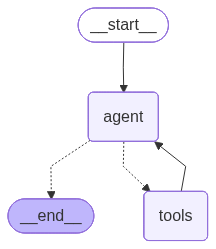

In [9]:
# ──────────────────────────────────────────────────────────────────────────────
# Assemble the LangGraph StateGraph
# ──────────────────────────────────────────────────────────────────────────────

def build_agent_graph(checkpointer=None) -> StateGraph:
    """Construct and compile the ReAct agent graph.

    Args:
        checkpointer: Optional LangGraph checkpointer for persistent memory.

    Returns:
        Compiled CompiledGraph ready to invoke.
    """
    graph = StateGraph(AgentState)

    # ── Nodes ─────────────────────────────────────────────────────────────────
    graph.add_node("agent", llm_node)
    graph.add_node("tools", tool_node)

    # ── Edges ─────────────────────────────────────────────────────────────────
    graph.add_edge(START, "agent")
    graph.add_conditional_edges("agent", should_continue, {"tools": "tools", END: END})
    graph.add_edge("tools", "agent")      # loop back for multi-hop reasoning

    return graph.compile(checkpointer=checkpointer)


# ── In-memory graph (fast, session-scoped) ───────────────────────────────────
memory_checkpointer = MemorySaver()
agent_graph = build_agent_graph(checkpointer=memory_checkpointer)

# ── Persistent SQLite graph (survives kernel restarts) ───────────────────────
_sqlite_conn = sqlite3.connect(AGENT_CONFIG["db_path"], check_same_thread=False)
sqlite_checkpointer = SqliteSaver(_sqlite_conn)
persistent_agent = build_agent_graph(checkpointer=sqlite_checkpointer)

print(" Agent graph compiled (in-memory + persistent SQLite versions)")
display(Image(agent_graph.get_graph().draw_mermaid_png()))


##  8. Invocation Helpers — Run, Stream, Pretty-Print

In [10]:
# ──────────────────────────────────────────────────────────────────────────────
# Helper utilities for clean, reusable agent invocation
# ──────────────────────────────────────────────────────────────────────────────

from typing import Iterator

_ROLE_ICONS = {
    "human":    " User",
    "ai":       " Agent",
    "tool":     " Tool",
    "system":   "  System",
}

def _role_icon(msg: AnyMessage) -> str:
    return _ROLE_ICONS.get(msg.type, f" {msg.type.capitalize()}")


def pretty_print_messages(messages: List[AnyMessage]) -> None:
    """Print a conversation thread with clear role labels and tool call details."""
    print("─" * 70)
    for msg in messages:
        icon = _role_icon(msg)
        # Tool calls embedded in AI message
        if isinstance(msg, AIMessage) and getattr(msg, "tool_calls", []):
            print(f"\n{icon}  [planning tool calls]")
            for tc in msg.tool_calls:
                args_str = json.dumps(tc.get("args", {}), indent=2)
                print(f"   ┌─ 🔧 {tc['name']}({args_str})")
        elif isinstance(msg, ToolMessage):
            print(f"\n{icon}  [{msg.name}] →")
            # Truncate very long tool outputs for readability
            content = str(msg.content)
            if len(content) > 600:
                content = content[:600] + "…  [truncated]"
            print(f"   {content}")
        elif msg.type == "system":
            pass   # skip system prompt in output
        else:
            print(f"\n{icon}")
            print(f"   {msg.content}")
    print("─" * 70)


def run_agent(
    query: str,
    *,
    graph=None,
    thread_id: str = "default",
    verbose: bool = True,
) -> Dict[str, Any]:
    """Invoke the agent on a single query.

    Args:
        query:     Natural language question or task.
        graph:     Which compiled graph to use (defaults to agent_graph).
        thread_id: Memory thread — same ID continues the conversation.
        verbose:   Whether to pretty-print the full message trace.

    Returns:
        Final state dict with 'messages' key.
    """
    if graph is None:
        graph = agent_graph

    config: RunnableConfig = {
        "configurable": {"thread_id": thread_id},
        "recursion_limit": AGENT_CONFIG["max_iterations"] + 5,
    }
    initial_state: AgentState = {
        "messages":        [HumanMessage(content=query)],
        "iteration_count": 0,
        "error_count":     0,
        "session_id":      thread_id,
    }

    start_time = time.perf_counter()
    logger.info(f"▶ Running agent | thread={thread_id!r} | query={query!r}")

    try:
        result = graph.invoke(initial_state, config=config)
    except Exception as exc:
        logger.error(f"Graph invocation failed: {exc}\n{traceback.format_exc()}")
        raise

    elapsed = time.perf_counter() - start_time
    logger.info(f" Completed in {elapsed:.2f}s | messages: {len(result['messages'])}")

    if verbose:
        pretty_print_messages(result["messages"])
        print(f"\n  Completed in {elapsed:.2f}s")

    return result


def stream_agent(
    query: str,
    *,
    graph=None,
    thread_id: str = "stream_default",
) -> None:
    """Stream agent output token-by-token (or node-by-node via LangGraph streaming)."""
    if graph is None:
        graph = agent_graph

    config: RunnableConfig = {
        "configurable": {"thread_id": thread_id},
        "recursion_limit": AGENT_CONFIG["max_iterations"] + 5,
    }
    initial_state: AgentState = {
        "messages":        [HumanMessage(content=query)],
        "iteration_count": 0,
        "error_count":     0,
        "session_id":      thread_id,
    }

    print(f" Streaming response for: {query!r}\n{'─'*60}")
    for event in graph.stream(initial_state, config=config, stream_mode="updates"):
        for node_name, node_output in event.items():
            msgs = node_output.get("messages", [])
            for msg in msgs:
                if isinstance(msg, AIMessage) and msg.content:
                    print(f"[{node_name}] {msg.content}")
                elif isinstance(msg, ToolMessage):
                    content_preview = str(msg.content)[:200]
                    print(f"[tool:{msg.name}] {content_preview}…")
    print("─" * 60)


print(" Invocation helpers ready: run_agent(), stream_agent(), pretty_print_messages()")


 Invocation helpers ready: run_agent(), stream_agent(), pretty_print_messages()


##  9. Demo: Multi-Tool Chained Reasoning

In [11]:
# ──────────────────────────────────────────────────────────────────────────────
# Demo 1 — Multi-step arithmetic (tests tool chaining)
# ──────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("DEMO 1 — Multi-step arithmetic")
print("=" * 70)

result1 = run_agent(
    "Add 15 and 27, then multiply the result by 4, and finally divide by 6.",
    thread_id="demo_math",
)


DEMO 1 — Multi-step arithmetic
──────────────────────────────────────────────────────────────────────

 User
   Add 15 and 27, then multiply the result by 4, and finally divide by 6.

 Agent  [planning tool calls]
   ┌─ 🔧 add({
  "a": 15,
  "b": 27
})
   ┌─ 🔧 multiply({
  "a": 42,
  "b": 4
})
   ┌─ 🔧 divide({
  "a": 168,
  "b": 6
})

🔧 Tool  [add] →
   15.0 + 27.0 = 42.0

🔧 Tool  [multiply] →
   42.0 × 4.0 = 168.0

🔧 Tool  [divide] →
   168.0 ÷ 6.0 = 28

 Agent
   The result of the operations is 28.
──────────────────────────────────────────────────────────────────────

  Completed in 0.71s


In [12]:
# ──────────────────────────────────────────────────────────────────────────────
# Demo 2 — Wikipedia knowledge lookup
# ──────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("DEMO 2 — Knowledge lookup via Wikipedia")
print("=" * 70)

result2 = run_agent(
    "What is the Transformer architecture in deep learning? Give a concise summary.",
    thread_id="demo_wiki",
)


DEMO 2 — Knowledge lookup via Wikipedia


ERROR:react_agent:LLM call failed (attempt 1): Error code: 400 - {'error': {'message': 'tool call validation failed: attempted to call tool \'wikipedia{"query": "Transformer (machine learning)"}\' which was not in request.tools', 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=wikipedia{"query": "Transformer (machine learning)"}></function>'}}


──────────────────────────────────────────────────────────────────────

User
   What is the Transformer architecture in deep learning? Give a concise summary.

 Agent
    I encountered an error while processing your request: `Error code: 400 - {'error': {'message': 'tool call validation failed: attempted to call tool \'wikipedia{"query": "Transformer (machine learning)"}\' which was not in request.tools', 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=wikipedia{"query": "Transformer (machine learning)"}></function>'}}`. Please try rephrasing, or check your API key configuration.
──────────────────────────────────────────────────────────────────────

 Completed in 0.37s


In [13]:
# ──────────────────────────────────────────────────────────────────────────────
# Demo 3 — Academic paper search (ArXiv)
# ──────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("DEMO 3 — ArXiv academic research")
print("=" * 70)

result3 = run_agent(
    "Find recent ArXiv papers about Retrieval Augmented Generation (RAG). "
    "Summarise the key ideas.",
    thread_id="demo_arxiv",
)


DEMO 3 — ArXiv academic research


ERROR:react_agent:LLM call failed (attempt 1): Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=arxiv_tool{"query": "Retrieval Augmented Generation (RAG)"}</function>'}}


──────────────────────────────────────────────────────────────────────

 User
   Find recent ArXiv papers about Retrieval Augmented Generation (RAG). Summarise the key ideas.

 Agent
    I encountered an error while processing your request: `Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=arxiv_tool{"query": "Retrieval Augmented Generation (RAG)"}</function>'}}`. Please try rephrasing, or check your API key configuration.
──────────────────────────────────────────────────────────────────────

  Completed in 0.26s


##  10. Persistent Memory — Multi-Turn Conversation

In [14]:
# ──────────────────────────────────────────────────────────────────────────────
# Multi-turn conversation — the agent remembers context within a thread_id
# ──────────────────────────────────────────────────────────────────────────────

THREAD = "memory_demo_001"   # same thread_id chains conversations

print("TURN 1 — Initial calculation")
run_agent("What is 17 multiplied by 13?", thread_id=THREAD)


TURN 1 — Initial calculation
──────────────────────────────────────────────────────────────────────

 User
   What is 17 multiplied by 13?

 Agent  [planning tool calls]
   ┌─ 🔧 multiply({
  "a": 17,
  "b": 13
})

🔧 Tool  [multiply] →
   17.0 × 13.0 = 221.0

 Agent
   The result of 17 multiplied by 13 is 221.
──────────────────────────────────────────────────────────────────────

  Completed in 0.64s


{'messages': [HumanMessage(content='What is 17 multiplied by 13?', additional_kwargs={}, response_metadata={}, id='03e0d22c-e14d-4387-9c7b-a44197064d0e'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'vws4tpd27', 'function': {'arguments': '{"a":17,"b":13}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1750, 'total_tokens': 1769, 'completion_time': 0.055930828, 'completion_tokens_details': None, 'prompt_time': 0.189720319, 'prompt_tokens_details': None, 'queue_time': 0.05412643, 'total_time': 0.245651147}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5d9c-0db4-79a1-b002-c2118904947a-0', tool_calls=[{'name': 'multiply', 'args': {'a': 17, 'b': 13}, 'id': 'vws4tpd27', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens

In [15]:
print("TURN 2 — References previous result (tests memory)")
run_agent(
    "Now add 500 to that result.",
    thread_id=THREAD,   # same thread — agent recalls the 221 from turn 1
)


TURN 2 — References previous result (tests memory)
──────────────────────────────────────────────────────────────────────

 User
   What is 17 multiplied by 13?

 Agent  [planning tool calls]
   ┌─ 🔧 multiply({
  "a": 17,
  "b": 13
})

 Tool  [multiply] →
   17.0 × 13.0 = 221.0

 Agent
   The result of 17 multiplied by 13 is 221.

 User
   Now add 500 to that result.

 Agent  [planning tool calls]
   ┌─  add({
  "a": 221,
  "b": 500
})

🔧 Tool  [add] →
   221.0 + 500.0 = 721.0

 Agent
   The result of adding 500 to 221 is 721.
──────────────────────────────────────────────────────────────────────

⏱  Completed in 12.01s


{'messages': [HumanMessage(content='What is 17 multiplied by 13?', additional_kwargs={}, response_metadata={}, id='03e0d22c-e14d-4387-9c7b-a44197064d0e'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'vws4tpd27', 'function': {'arguments': '{"a":17,"b":13}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1750, 'total_tokens': 1769, 'completion_time': 0.055930828, 'completion_tokens_details': None, 'prompt_time': 0.189720319, 'prompt_tokens_details': None, 'queue_time': 0.05412643, 'total_time': 0.245651147}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5d9c-0db4-79a1-b002-c2118904947a-0', tool_calls=[{'name': 'multiply', 'args': {'a': 17, 'b': 13}, 'id': 'vws4tpd27', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens

In [16]:
print("TURN 3 — Further chaining")
run_agent(
    "Divide that by 7 and tell me what you get.",
    thread_id=THREAD,
)


TURN 3 — Further chaining
──────────────────────────────────────────────────────────────────────

 User
   What is 17 multiplied by 13?

 Agent  [planning tool calls]
   ┌─ 🔧 multiply({
  "a": 17,
  "b": 13
})

🔧 Tool  [multiply] →
   17.0 × 13.0 = 221.0

 Agent
   The result of 17 multiplied by 13 is 221.

 User
   Now add 500 to that result.

 Agent  [planning tool calls]
   ┌─  add({
  "a": 221,
  "b": 500
})

🔧 Tool  [add] →
   221.0 + 500.0 = 721.0

 Agent
   The result of adding 500 to 221 is 721.

 User
   Divide that by 7 and tell me what you get.

 Agent  [planning tool calls]
   ┌─  divide({
  "a": 721,
  "b": 7
})

 Tool  [divide] →
   721.0 ÷ 7.0 = 103

 Agent
   The result of dividing 721 by 7 is 103.
──────────────────────────────────────────────────────────────────────

  Completed in 20.23s


{'messages': [HumanMessage(content='What is 17 multiplied by 13?', additional_kwargs={}, response_metadata={}, id='03e0d22c-e14d-4387-9c7b-a44197064d0e'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'vws4tpd27', 'function': {'arguments': '{"a":17,"b":13}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1750, 'total_tokens': 1769, 'completion_time': 0.055930828, 'completion_tokens_details': None, 'prompt_time': 0.189720319, 'prompt_tokens_details': None, 'queue_time': 0.05412643, 'total_time': 0.245651147}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5d9c-0db4-79a1-b002-c2118904947a-0', tool_calls=[{'name': 'multiply', 'args': {'a': 17, 'b': 13}, 'id': 'vws4tpd27', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens

##  11. SQLite Persistent Memory
Survives kernel restarts — ideal for production or long-running notebooks.


In [17]:
# ──────────────────────────────────────────────────────────────────────────────
# persistent_agent uses SQLite — conversations survive kernel restart
# ──────────────────────────────────────────────────────────────────────────────
PERSIST_THREAD = "persistent_session_42"

print("Persistent agent — Turn 1")
run_agent(
    "Remember that my project budget is $50,000.",
    graph=persistent_agent,
    thread_id=PERSIST_THREAD,
)


Persistent agent — Turn 1
──────────────────────────────────────────────────────────────────────

 User
   Remember that my project budget is $50,000.

 Agent
   I don't have any information about your project budget. This is the beginning of our conversation, and I don't retain any information from previous conversations. If you'd like to discuss your project budget, I'd be happy to help. What would you like to know or discuss about your project budget of $50,000?

 User
   What is 15% of my project budget?

 Agent  [planning tool calls]
   ┌─ 🔧 multiply({
  "a": 50000,
  "b": 0.15
})

 Tool  [multiply] →
   50000.0 × 0.15 = 7500.0

 Agent
   15% of your project budget is $7,500.

 User
   Remember that my project budget is $50,000.

 Agent
   I've taken note that your project budget is $50,000. I'll keep this in mind for any future calculations or discussions related to your project.
──────────────────────────────────────────────────────────────────────

  Completed in 29.74s


{'messages': [HumanMessage(content='Remember that my project budget is $50,000.', additional_kwargs={}, response_metadata={}, id='d7f4a78d-1147-4c19-888b-4af6549a4c86'),
  AIMessage(content="I don't have any information about your project budget. This is the beginning of our conversation, and I don't retain any information from previous conversations. If you'd like to discuss your project budget, I'd be happy to help. What would you like to know or discuss about your project budget of $50,000?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 1752, 'total_tokens': 1818, 'completion_time': 0.174536664, 'completion_tokens_details': None, 'prompt_time': 0.109810125, 'prompt_tokens_details': None, 'queue_time': 0.054063885, 'total_time': 0.284346789}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--

In [18]:
print("Persistent agent — Turn 2  (would recall even after restart)")
run_agent(
    "What is 15% of my project budget?",
    graph=persistent_agent,
    thread_id=PERSIST_THREAD,
)


Persistent agent — Turn 2  (would recall even after restart)
──────────────────────────────────────────────────────────────────────

 User
   Remember that my project budget is $50,000.

 Agent
   I don't have any information about your project budget. This is the beginning of our conversation, and I don't retain any information from previous conversations. If you'd like to discuss your project budget, I'd be happy to help. What would you like to know or discuss about your project budget of $50,000?

 User
   What is 15% of my project budget?

 Agent  [planning tool calls]
   ┌─ 🔧 multiply({
  "a": 50000,
  "b": 0.15
})

🔧 Tool  [multiply] →
   50000.0 × 0.15 = 7500.0

 Agent
   15% of your project budget is $7,500.

 User
   Remember that my project budget is $50,000.

 Agent
   I've taken note that your project budget is $50,000. I'll keep this in mind for any future calculations or discussions related to your project.

 User
   What is 15% of my project budget?

 Agent  [planning to

{'messages': [HumanMessage(content='Remember that my project budget is $50,000.', additional_kwargs={}, response_metadata={}, id='d7f4a78d-1147-4c19-888b-4af6549a4c86'),
  AIMessage(content="I don't have any information about your project budget. This is the beginning of our conversation, and I don't retain any information from previous conversations. If you'd like to discuss your project budget, I'd be happy to help. What would you like to know or discuss about your project budget of $50,000?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 1752, 'total_tokens': 1818, 'completion_time': 0.174536664, 'completion_tokens_details': None, 'prompt_time': 0.109810125, 'prompt_tokens_details': None, 'queue_time': 0.054063885, 'total_time': 0.284346789}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--

##  12. Streaming Demo

In [19]:
# ──────────────────────────────────────────────────────────────────────────────
# Streaming — observe the agent's reasoning and tool calls as they happen
# ──────────────────────────────────────────────────────────────────────────────
stream_agent(
    "What is the square root of 1764, and what is today's date?",
    thread_id="stream_test",
)


 Streaming response for: "What is the square root of 1764, and what is today's date?"
────────────────────────────────────────────────────────────
[tool:calculate] sqrt(1764) = 42.0…
[tool:get_current_datetime] Current UTC datetime: 2026-05-25 05:30:40 (requested tz: UTC)…
[agent] The square root of 1764 is 42.0, and today's date is 2026-05-25.
────────────────────────────────────────────────────────────


##  13. Robustness — Error Handling Demo

In [20]:
# ──────────────────────────────────────────────────────────────────────────────
# The agent handles edge cases gracefully instead of crashing
# ──────────────────────────────────────────────────────────────────────────────

print("Edge case 1 — Division by zero")
run_agent("What is 42 divided by 0?", thread_id="error_test_1")


Edge case 1 — Division by zero
──────────────────────────────────────────────────────────────────────

 User
   What is 42 divided by 0?

 Agent  [planning tool calls]
   ┌─  divide({
  "a": 42,
  "b": 0
})

 Tool  [divide] →
    Error: Division by zero is undefined.

 Agent
   The result of 42 divided by 0 is undefined, as division by zero is not allowed in mathematics.
──────────────────────────────────────────────────────────────────────

  Completed in 17.07s


{'messages': [HumanMessage(content='What is 42 divided by 0?', additional_kwargs={}, response_metadata={}, id='301c5004-6fa1-48a6-8867-08ff8ca851f0'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'xyp9shxrc', 'function': {'arguments': '{"a":42,"b":0}', 'name': 'divide'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1750, 'total_tokens': 1769, 'completion_time': 0.057209593, 'completion_tokens_details': None, 'prompt_time': 0.265437579, 'prompt_tokens_details': None, 'queue_time': 0.209439846, 'total_time': 0.322647172}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5d9d-49ca-7fd1-8830-9005b814463f-0', tool_calls=[{'name': 'divide', 'args': {'a': 42, 'b': 0}, 'id': 'xyp9shxrc', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1750, 

In [21]:
print("Edge case 2 — Ambiguous expression")
run_agent("Calculate: sqrt(-1)", thread_id="error_test_2")


Edge case 2 — Ambiguous expression
──────────────────────────────────────────────────────────────────────

 User
   Calculate: sqrt(-1)

 Agent  [planning tool calls]
   ┌─  calculate({
  "expression": "sqrt(-1)"
})

 Tool  [calculate] →
    Could not evaluate 'sqrt(-1)': math domain error

 Agent
   The square root of -1 is an imaginary number, denoted by i. It is defined as the square root of -1, and it is used to extend the real number system to the complex number system. In mathematics, i is defined as the imaginary unit, which satisfies the equation i^2 = -1.
──────────────────────────────────────────────────────────────────────

 Completed in 19.01s


{'messages': [HumanMessage(content='Calculate: sqrt(-1)', additional_kwargs={}, response_metadata={}, id='bdbade2d-6e97-4301-8166-a99cccdc645c'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'me4ftt8ct', 'function': {'arguments': '{"expression":"sqrt(-1)"}', 'name': 'calculate'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 1747, 'total_tokens': 1763, 'completion_time': 0.038422254, 'completion_tokens_details': None, 'prompt_time': 0.165902844, 'prompt_tokens_details': None, 'queue_time': 0.0368206, 'total_time': 0.204325098}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5d9d-8c81-7362-bc39-e69baf1f8550-0', tool_calls=[{'name': 'calculate', 'args': {'expression': 'sqrt(-1)'}, 'id': 'me4ftt8ct', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'in

##  14. Inspect Conversation History

In [22]:
# ──────────────────────────────────────────────────────────────────────────────
# Inspect the stored state for any thread
# ──────────────────────────────────────────────────────────────────────────────

def inspect_thread(thread_id: str, graph=None) -> None:
    """Print the stored message history for a given thread."""
    if graph is None:
        graph = agent_graph
    config = {"configurable": {"thread_id": thread_id}}
    try:
        state = graph.get_state(config)
        messages = state.values.get("messages", [])
        print(f"\n Thread '{thread_id}' — {len(messages)} messages stored")
        pretty_print_messages(messages)
    except Exception as e:
        print(f" Could not retrieve thread '{thread_id}': {e}")


inspect_thread("memory_demo_001")



 Thread 'memory_demo_001' — 12 messages stored
──────────────────────────────────────────────────────────────────────

 User
   What is 17 multiplied by 13?

 Agent  [planning tool calls]
   ┌─  multiply({
  "a": 17,
  "b": 13
})

 Tool  [multiply] →
   17.0 × 13.0 = 221.0

 Agent
   The result of 17 multiplied by 13 is 221.

 User
   Now add 500 to that result.

 Agent  [planning tool calls]
   ┌─ 🔧 add({
  "a": 221,
  "b": 500
})

🔧 Tool  [add] →
   221.0 + 500.0 = 721.0

 Agent
   The result of adding 500 to 221 is 721.

 User
   Divide that by 7 and tell me what you get.

 Agent  [planning tool calls]
   ┌─ 🔧 divide({
  "a": 721,
  "b": 7
})

 Tool  [divide] →
   721.0 ÷ 7.0 = 103

 Agent
   The result of dividing 721 by 7 is 103.
──────────────────────────────────────────────────────────────────────


In [23]:
# !pip uninstall -y arxiv
# !pip install arxiv==1.4.8

In [26]:
!pip install --upgrade wikipedia

##  15. Direct Tool Unit Tests

In [28]:
# ──────────────────────────────────────────────────────────────────────────────
# Smoke-test every tool in isolation before plugging into the agent
# ──────────────────────────────────────────────────────────────────────────────

print("── Math Tools ────────────────────────────────")

try:
    print(add.invoke({"a": 123, "b": 456}))
    print(subtract.invoke({"a": 1000, "b": 337}))
    print(multiply.invoke({"a": 7, "b": 8}))
    print(divide.invoke({"a": 22, "b": 7}))
    print(divide.invoke({"a": 1, "b": 0}))  # error path
    print(power.invoke({"base": 2, "exponent": 10}))
    print(calculate.invoke({"expression": "sqrt(144) + 2**8 - 100"}))
    print(calculate.invoke({"expression": "pi * 5**2"}))
except Exception as e:
    print(f" Math tool error: {e}")

# ──────────────────────────────────────────────────────────────────────────────

print("\n── Datetime Tool ─────────────────────────────")

try:
    print(get_current_datetime.invoke({"timezone": "IST"}))
except Exception as e:
    print(f" Datetime tool error: {e}")

# ──────────────────────────────────────────────────────────────────────────────

print("\n── Wikipedia ─────────────────────────────────")

try:
    wiki_result = wiki_tool.invoke("LangChain framework")
    print(wiki_result[:300], "…")
except Exception as e:
    print(f" Wikipedia tool error: {e}")

# ──────────────────────────────────────────────────────────────────────────────

print("\n── ArXiv ─────────────────────────────────────")

try:
    arxiv_result = arxiv_tool.invoke("large language model agents")
    print(arxiv_result[:300], "…")
except Exception as e:
    print(f" ArXiv tool error: {e}")

# ──────────────────────────────────────────────────────────────────────────────

print("\n Smoke test completed")

── Math Tools ────────────────────────────────
123.0 + 456.0 = 579.0
1000.0 - 337.0 = 663.0
7.0 × 8.0 = 56.0
22.0 ÷ 7.0 = 3.14286
 Error: Division by zero is undefined.
2.0^10.0 = 1024
sqrt(144) + 2**8 - 100 = 168.0
pi * 5**2 = 78.53981633974483

── Datetime Tool ─────────────────────────────
Current UTC datetime: 2026-05-25 05:33:34 (requested tz: IST)

── Wikipedia ─────────────────────────────────
 Wikipedia tool error: Expecting value: line 1 column 1 (char 0)

── ArXiv ─────────────────────────────────────
 ArXiv tool error: Page request resulted in HTTP 301: None (http://export.arxiv.org/api/query?search_query=large+language+model+agents&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=3)

 Smoke test completed


##  16. Session Analytics & Summary

In [29]:
# ──────────────────────────────────────────────────────────────────────────────
# Summary of all active threads in the in-memory checkpointer
# ──────────────────────────────────────────────────────────────────────────────

def session_summary(graph=None) -> None:
    """Print a summary of all conversation threads currently in memory."""
    if graph is None:
        graph = agent_graph
    try:
        snapshots = list(graph.get_state_history(
            {"configurable": {"thread_id": "__ALL__"}}
        ))
    except Exception:
        snapshots = []

    print("\n Session Summary")
    print("─" * 50)
    print(f"  In-memory checkpointer: {type(memory_checkpointer).__name__}")
    print(f"  SQLite db path:         {AGENT_CONFIG['db_path']}")
    print(f"  Max iterations / run:   {AGENT_CONFIG['max_iterations']}")
    print(f"  Primary model:          {AGENT_CONFIG['primary_model']}")
    print(f"  Tools available:        {len(ALL_TOOLS)}")
    print(f"  Snapshots in history:   {len(snapshots)}")
    print("─" * 50)


session_summary()
print("\n Production ReAct Agent fully operational!")



 Session Summary
──────────────────────────────────────────────────
  In-memory checkpointer: InMemorySaver
  SQLite db path:         agent_memory.db
  Max iterations / run:   10
  Primary model:          llama-3.3-70b-versatile
  Tools available:        10
  Snapshots in history:   0
──────────────────────────────────────────────────

 Production ReAct Agent fully operational!


##  17. What's Next — Extending This Agent

| Feature | How to add |
|---|---|
| **OpenAI GPT-4o** | Swap `ChatGroq` for `ChatOpenAI` and set `OPENAI_API_KEY` |
| **Custom RAG tool** | Add a `@tool` that queries a vector DB (Chroma / Pinecone) |
| **Human-in-the-loop** | Add `interrupt_before=["tools"]` to `graph.compile()` |
| **Async execution** | Use `await graph.ainvoke(...)` in async contexts |
| **FastAPI deployment** | Wrap `run_agent()` in a FastAPI endpoint with streaming |
| **Evaluation** | Use LangSmith datasets to benchmark answer quality |
| **Multi-agent** | Compose multiple specialised agents as sub-graphs |
| **File I/O tool** | `@tool` that reads/writes local files for document tasks |
